## Setup
<hr>

In [1]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Crips Sets vs. Fuzzy Sets
<hr>

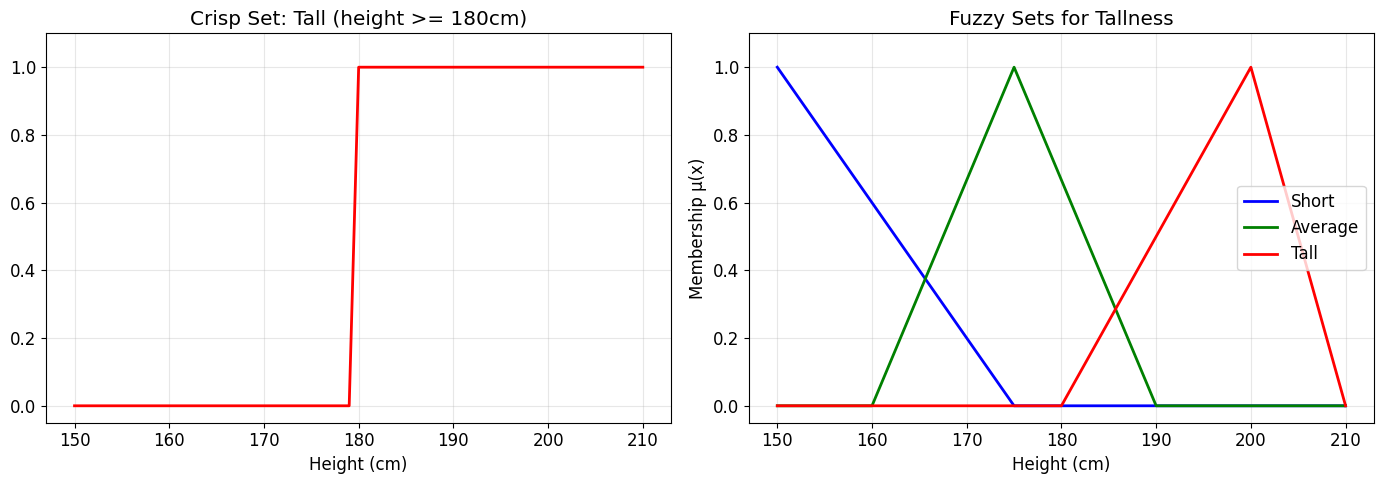

A person who is 184 cm tall:
 μ_average(184) = 0.40
 μ_tall(184) = 0.20
 → Partial membership in MULTIPLE sets simultaneously.


In [2]:
# Universe of discourse: height in cm
x_height = np.arange(150, 211, 1)

# --- Crisp set: tall if height >= 180 ---
crisp_tall = np.where(x_height >= 180, 1.0, 0.0)

# --- Fuzzy sets ---
short = fuzz.trimf(x_height, [150, 150, 175])
average = fuzz.trimf(x_height, [160, 175, 190])
tall = fuzz.trimf(x_height, [180, 200, 210])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Crisp
ax1.plot(x_height, crisp_tall, 'r-', linewidth=2)
ax1.set_title('Crisp Set: Tall (height >= 180cm)')
ax1.set_xlabel('Height (cm)')
ax1.set_label('Membership')
ax1.set_ylim(-0.05, 1.1)

# Fuzzy
ax2.plot(x_height, short, 'b-', linewidth=2, label='Short')
ax2.plot(x_height, average, 'g-', linewidth=2, label='Average')
ax2.plot(x_height, tall, 'r-', linewidth=2, label='Tall')
ax2.set_title('Fuzzy Sets for Tallness')
ax2.set_xlabel('Height (cm)')
ax2.set_ylabel('Membership μ(x)')
ax2.set_ylim(-0.05, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

# Demonstrate partial membership
height = 184
mu_avg = fuzz.interp_membership(x_height, average, height)
mu_tall = fuzz.interp_membership(x_height, tall, height)

print(f"A person who is {height} cm tall:")
print(f" μ_average({height}) = {mu_avg:.2f}")
print(f" μ_tall({height}) = {mu_tall:.2f}")
print(f" → Partial membership in MULTIPLE sets simultaneously.")

## 2. Common Membership Functions
<hr>

### 2.1: Plot All Four Membership Function Types

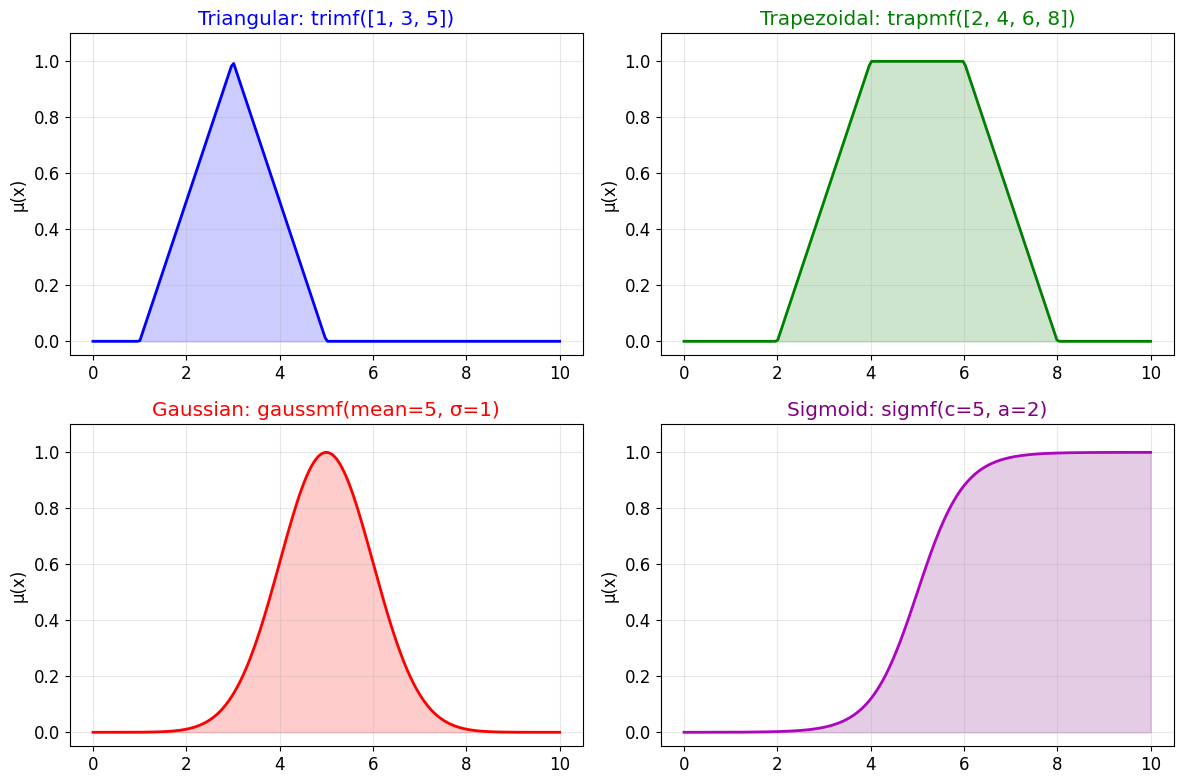

In [13]:
x = np.linspace(0, 10, 200)

# Triangular: peak at 3
mf_tri = fuzz.trimf(x, [1, 3, 5])

# Trapezoidal: plateau from 4 to 6
mf_trap = fuzz.trapmf(x, [2, 4, 6, 8])

# Gaussian: centred at 5, sigma=1
mf_gauss = fuzz.gaussmf(x, mean=5, sigma=1)

# Sigmoid: inflection at 5, slope=2 (positive = rising)
mf_sig = fuzz.sigmf(x, 5, 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x, mf_tri, 'b-', linewidth=2)
axes[0, 0].set_title('Triangular: trimf([1, 3, 5])', color='b')
axes[0, 0].fill_between(x, mf_tri, alpha=0.2, color='b')

axes[0, 1].plot(x, mf_trap, 'g-', linewidth=2)
axes[0, 1].set_title('Trapezoidal: trapmf([2, 4, 6, 8])', color='g')
axes[0, 1].fill_between(x, mf_trap, alpha=0.2, color='g')

axes[1, 0].plot(x, mf_gauss, 'r-', linewidth=2)
axes[1, 0].set_title('Gaussian: gaussmf(mean=5, σ=1)', color='r')
axes[1, 0].fill_between(x, mf_gauss, alpha=0.2, color='r')

axes[1, 1].plot(x, mf_sig, '#ad06bf', linewidth=2)
axes[1, 1].set_title('Sigmoid: sigmf(c=5, a=2)', color='purple')
axes[1, 1].fill_between(x, mf_sig, alpha=0.2, color='purple')


for ax in axes.flat:
    ax.set_label('x')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### 2.2: The Dapping Example — Defining Linguistic Variables

In [ ]:
# --- Define universe of discourse ---
x_wind = np.arange(0, 13, 0.1)  # Beaufort scale 0-12
x_temp = np.arange(0, 31, 0.1)
x_dapp = np.arange(0, 101, 1)

# --- Wind membership functions ---
wind_calm = fuzz.trimf(x_wind, [0, 0, 5])
wind_fresh = fuzz.trimf(x_wind, [2, 6, 10])
wind_stormy = fuzz.trimf(x_wind, [7, 12, 12])

# --- Temperature membership functions ---
temp_low = fuzz.trimf(x_temp, [0, 0, 12])
temp_average = fuzz.trimf(x_temp, [5, 15, 25])
temp_high = fuzz.trimf(x_temp, [17, 30, 30])

# --- Dapping ---
dapp_poor = fuzz.trimf(x_dapp, [0, 0, 50])
dapp_mediocre = fuzz.trimf(x_dapp, [10, 50, 90])
dapp_excellent = fuzz.trimf(x_dapp, [50, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Wind
ax1.plot(x_wind, wind_calm, 'b-', linewidth=2, label='Calm')
ax1.plot(x_wind, wind_fresh, 'g-', linewidth=2, label='Fresh')
ax1.plot(x_wind, wind_stormy, 'r-', linewidth=2, label='Stormy')
ax1.set_title('Wind (Beaufort Scale)')
ax1.set_xlabel('Beaufort Scale [0–12]')
ax1.set_ylabel('μ(x)')
ax1.legend()

# Temperature
ax2.plot(x_temp, temp_low, 'b-', linewidth=2, label='Low')
ax2.plot(x_temp, temp_average, 'g-', linewidth=2, label='Average')
ax2.plot(x_temp, temp_high, 'r-', linewidth=2, label='High')
ax2.set_title('Temperature (°C)')
ax2.set_xlabel('Temp °C')
ax2.set_ylabel('μ(x)')
ax2.legend()

# Dapping
ax3.plot(x_dapp, dapp_poor, 'b-', linewidth=2, label='Low')
ax3.plot(x_dapp, dapp_mediocre, 'g-', linewidth=2, label='Average')
ax3.plot(x_dapp, dapp_excellent, 'r-', linewidth=2, label='High')
ax3.set_title('DApping (%)')
ax3.set_xlabel('Temp °C')
ax3.set_ylabel('μ(x)')
ax3.legend()
